# Project Big Data - Notebook Group 22; Amazon Books

## Datasets Import and Setup
In the following block we import the datasets and prepare them for further usage.

In [29]:
import warnings

warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import sklearn as skl
import pycountry
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CUR_DIR = os.getcwd()
BOOKS_DATA_PATH = os.path.join(CUR_DIR, "books_data/books.csv")
RATINGS_DATA_PATH = os.path.join(CUR_DIR, "books_data/ratings.csv")
USERS_DATA_PATH = os.path.join(CUR_DIR, "books_data/users.csv")

df_books = pd.read_csv(BOOKS_DATA_PATH, encoding = 'latin-1', sep = ';', quotechar='"', escapechar="\\").drop(columns = ['Image-URL-S', 'Image-URL-M', 'Image-URL-L'])
df_ratings = pd.read_csv(RATINGS_DATA_PATH, encoding = 'latin-1', sep = ';', quotechar='"')
df_users = pd.read_csv(USERS_DATA_PATH, encoding = 'latin-1', sep = ';', quotechar='"', escapechar="\\", index_col=0)

print(f"Books data    loaded {len(df_books):,} rows, {df_books.shape[1]} columns.")
print(f"Ratings data  loaded {len(df_ratings):,} rows, {df_ratings.shape[1]} columns.")
print(f"Users data    loaded {len(df_users):,} rows, {df_users.shape[1]} columns.")

df_active_countries = df_users['Location'].str.split(',').str[-1].str.strip()
unique_active_countries = df_active_countries.unique()

Books data    loaded 271,379 rows, 5 columns.
Ratings data  loaded 1,149,780 rows, 3 columns.
Users data    loaded 278,858 rows, 2 columns.


In the block below we define a list of countries that will be used further. This is a step of cleaning customers data, so we are left only with realistic and standardized countries where customers originate from. A "realistic and standardized country" is a relative term; primarily it is interpreted as the english name or abbreviation of a country's name.

We use a two-step validation method where we first obtain a list of mutual countries and teritories, present in the dataset and in the python library pycountry, storing official names of most countries in the world (METHOD 1). Then (in METHOD 2) we check the data from countries with more than 50 customers, and compare if we are missing any country from the "mutual" list. We manually add those missing countries to the "mutual" list and then we convert the ones that have two names in the dataframe using a map (example is 'usa' that was manually added due to a big proportion being under that name and 'united states'). 

At the end we preserved about 98% of the users from the original set, organizing them in each country accordingly. The other 2% is removed due to the unstandardized nature of the addresses. Note, there are two countries with more than 50 users, that we decided not to include: "españa" due to having about 65 customers, while the majority has correctly used the standard "spain", and "yugoslavia" due to having about 180 customers, however the country no longer existing.

In [30]:
"""
METHOD 1
"""
countries = []
for country in pycountry.countries:
    countries.append(country.name.lower())

mutual = []
for mutual_country in countries:
    if mutual_country in unique_active_countries:
        mutual.append(mutual_country)

#ADD MANUALLY countries not in mutual
mutual += "usa", "russia", "u.a.e", "turkey", "españa", "iran", "vietnam", "taiwan", "syria", "venezuela", "south korea", "czech republic"
 
total_users_method1 = 0
for country in mutual:
    total_users_method1 += df_active_countries[df_active_countries == country].count()
print(f"Percentage of users kept after cleaning;            METHOD 1: {round(total_users_method1/len(df_users)*100, 2)}")

"""
METHOD 2
this is an additional validation step of the mutual list
"""
countries_counts = df_active_countries.value_counts()
counts_list = countries_counts[countries_counts>50].index.tolist()
counts_list.remove("")

total_users_method2 = 0
for country in counts_list:
    total_users_method2 += df_active_countries[df_active_countries == country].count()
print(f"Percentage of users kept after cleaning; only using METHOD 2: {round(total_users_method2/len(df_users)*100, 2)}")
print(f"Countries, having more than 50 customers, excluded from the countries list are: {set(counts_list)- set(mutual)}")

df_users['Country'] = df_users['Location'].str.split(',').str[-1].str.strip().str.lower()
df_users['Country'] = df_users['Country'].apply(lambda x: x if x in mutual else "unknown")

countries_map = {'usa' : 'united states',
                 'russian federation' : 'russia',
                 'türkiye' : 'turkey',
                 'u.a.e' : 'united arab emirates',
                 'españa' : 'spain',
                 'hong kong': 'china',
            }
df_users['Country'] = df_users['Country'].replace(countries_map)

df_users = df_users.drop(columns = ['Location'])

Percentage of users kept after cleaning;            METHOD 1: 97.94
Percentage of users kept after cleaning; only using METHOD 2: 97.38
Countries, having more than 50 customers, excluded from the countries list are: {'yugoslavia'}


## Exploratory Data Analysis (EDA)
This section explores the three original datasets before building the recommendation model. The goal is to understand the structure of the data, check missing values, inspect important variables, and identify possible limitations that may affect the model later.

### Dataset overview
This section explores the three original datasets before building the recommendation model.

In [31]:
datasets = {
    "books": df_books,
    "ratings": df_ratings,
    "users": df_users
}

for name, df in datasets.items():
    print(f"\n{name.upper()} DATASET")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print("Duplicate rows:", df.duplicated().sum())
    print("Missing values:", df.isnull().sum().sum())


BOOKS DATASET
Rows: 271379
Columns: 5
Duplicate rows: 0
Missing values: 4

RATINGS DATASET
Rows: 1149780
Columns: 3
Duplicate rows: 0
Missing values: 0

USERS DATASET
Rows: 278858
Columns: 2
Duplicate rows: 274528
Missing values: 110762


### Books Dataset
We explore the books dataset. We check the number of unique books, missing values, and the most common authors and publishers. This helps us understand which books and publishers are most represented in the data.

Data Types of Books Dataset:

 ISBN                   object
Book-Title             object
Book-Author            object
Year-Of-Publication     int64
Publisher              object
dtype: object

Number of unique books: 271379

Missing values in books dataset:
 ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
dtype: int64


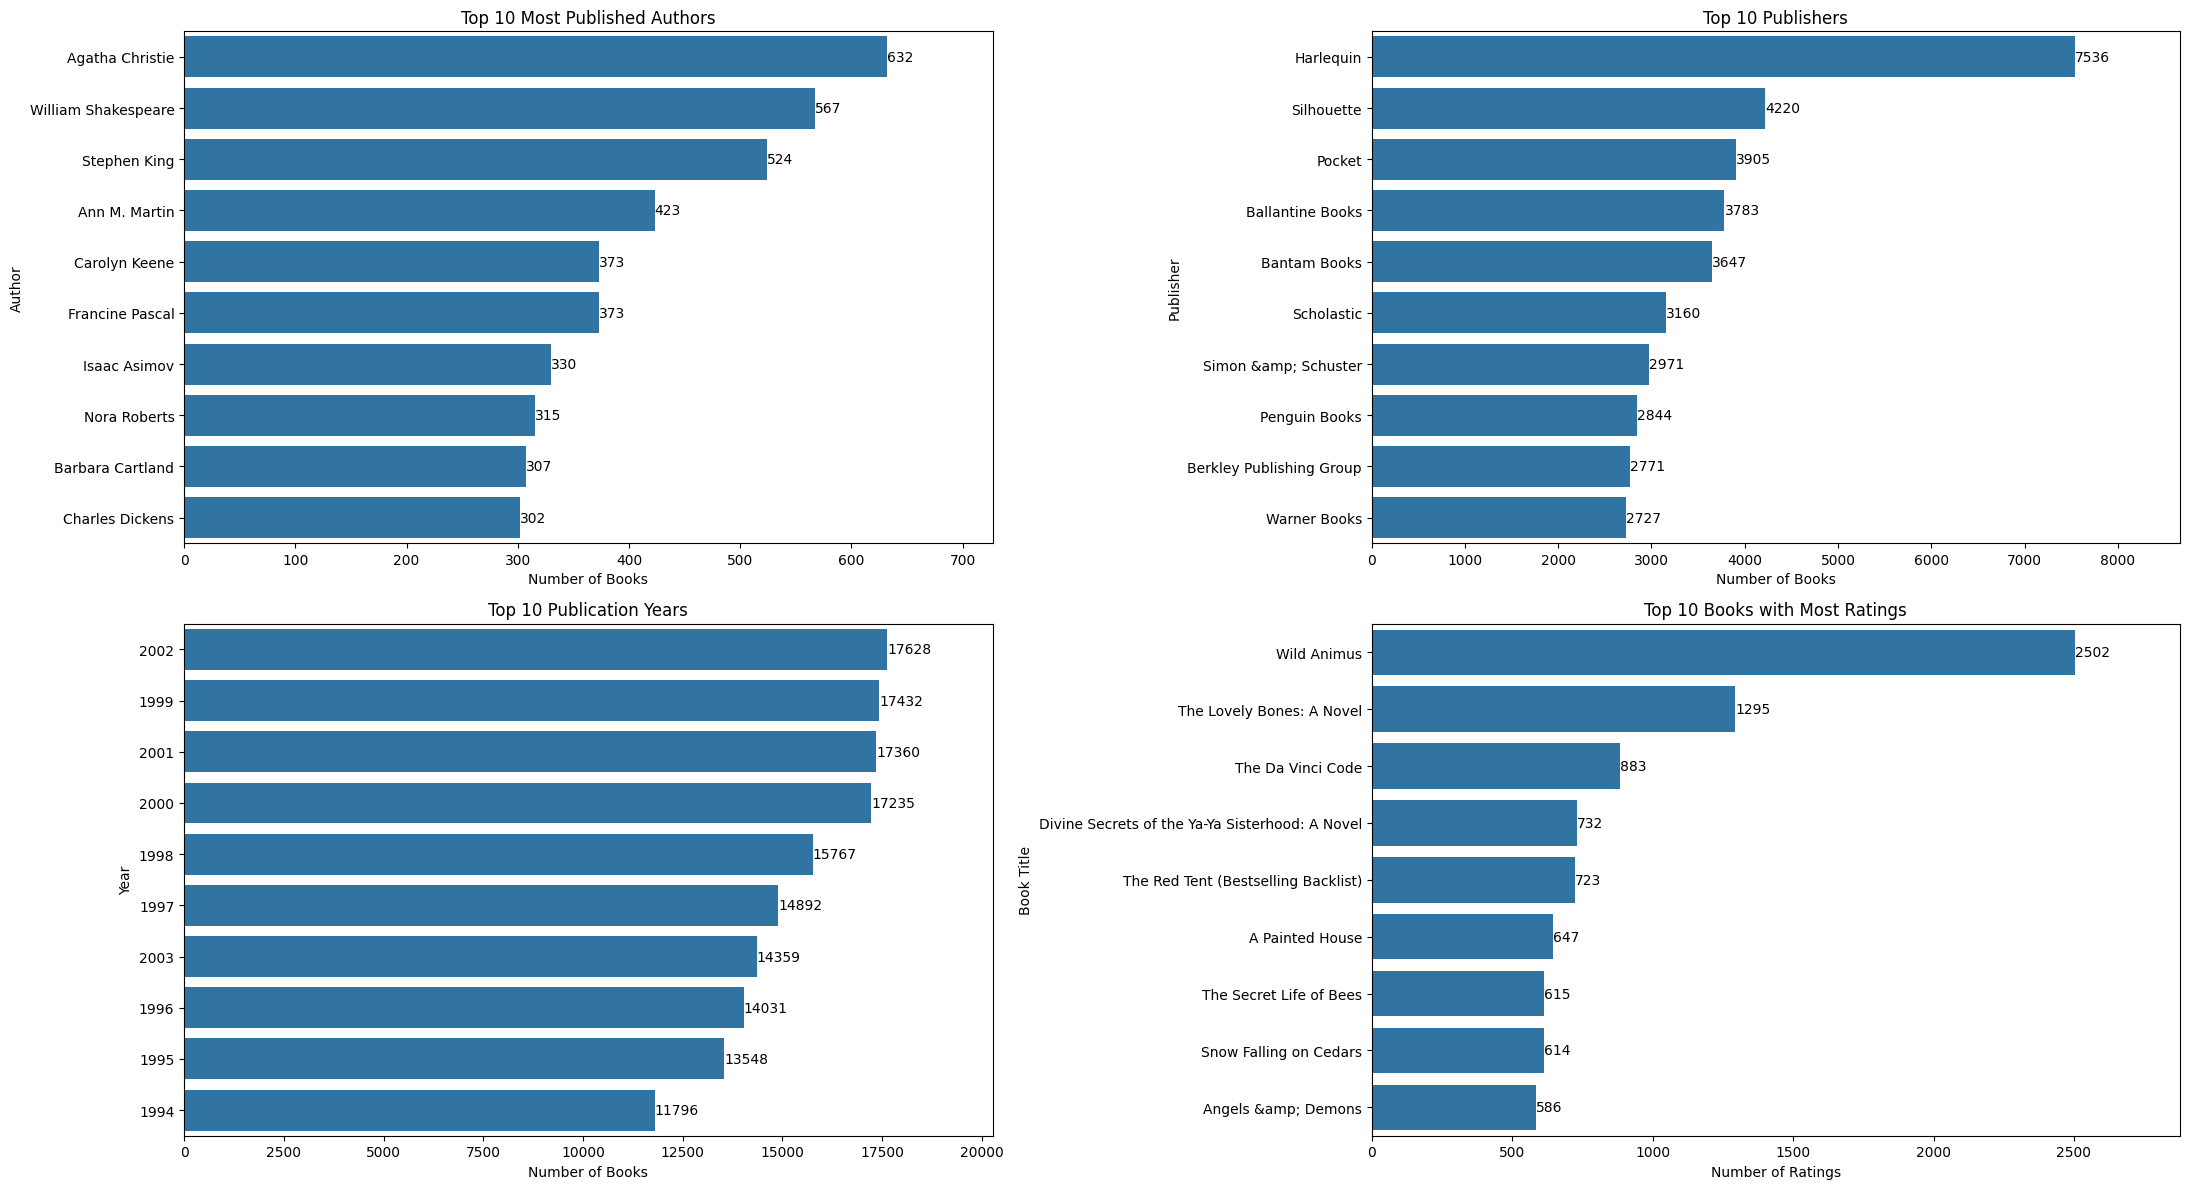

In [34]:
print("Data Types of Books Dataset:")
print("\n", df_books.dtypes)

print("\nNumber of unique books:", df_books["ISBN"].nunique())
print("\nMissing values in books dataset:\n", df_books.isnull().sum())


top_n = 10

author_count = (
    df_books["Book-Author"]
    .value_counts()
    .head(top_n)
    .reset_index()
)
author_count.columns = ["Book-Author", "Count"]

publisher_count = (
    df_books["Publisher"]
    .value_counts()
    .head(top_n)
    .reset_index()
)
publisher_count.columns = ["Publisher", "Count"]

year_count = (
    df_books[df_books["Year-Of-Publication"].notna()]
    ["Year-Of-Publication"]
    .astype(int)
    .value_counts()
    .head(top_n)
    .reset_index()
)
year_count.columns = ["Year-Of-Publication", "Count"]
year_count["Year-Of-Publication"] = year_count["Year-Of-Publication"].astype(str)

most_rated_books = (
    df_ratings
    .groupby("ISBN")
    .size()
    .reset_index(name="Count")
    .merge(df_books[["ISBN", "Book-Title"]].drop_duplicates("ISBN"),on="ISBN",how="left")
    .sort_values("Count", ascending=False)
    .head(top_n)
)

fig, axes = plt.subplots(2, 2, figsize=(22, 12))

ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]

sns.barplot(data=author_count, y="Book-Author", x="Count", ax=ax1)
ax1.set_title("Top 10 Most Published Authors")
ax1.set_xlabel("Number of Books")
ax1.set_ylabel("Author")

sns.barplot(data=publisher_count, y="Publisher", x="Count", ax=ax2)
ax2.set_title("Top 10 Publishers")
ax2.set_xlabel("Number of Books")
ax2.set_ylabel("Publisher")

sns.barplot(data=year_count, y="Year-Of-Publication", x="Count", ax=ax3)
ax3.set_title("Top 10 Publication Years")
ax3.set_xlabel("Number of Books")
ax3.set_ylabel("Year")

sns.barplot(data=most_rated_books, y="Book-Title", x="Count", ax=ax4)
ax4.set_title("Top 10 Books with Most Ratings")
ax4.set_xlabel("Number of Ratings")
ax4.set_ylabel("Book Title")

for ax in [ax1, ax2, ax3, ax4]:
    ax.bar_label(ax.containers[0])
    ax.margins(x=0.15)

plt.tight_layout()
plt.show()

### Ratings Dataset
Here we explore the ratings dataset. We check how many users and books appear in the ratings table and look at the distribution of ratings.

Data Types of Ratings Dataset:

 User-ID         int64
ISBN           object
Book-Rating     int64
dtype: object

Number of unique rated books: 340556
Number of unique rating users: 105283

Missing values in ratings dataset:
 User-ID        0
ISBN           0
Book-Rating    0
dtype: int64


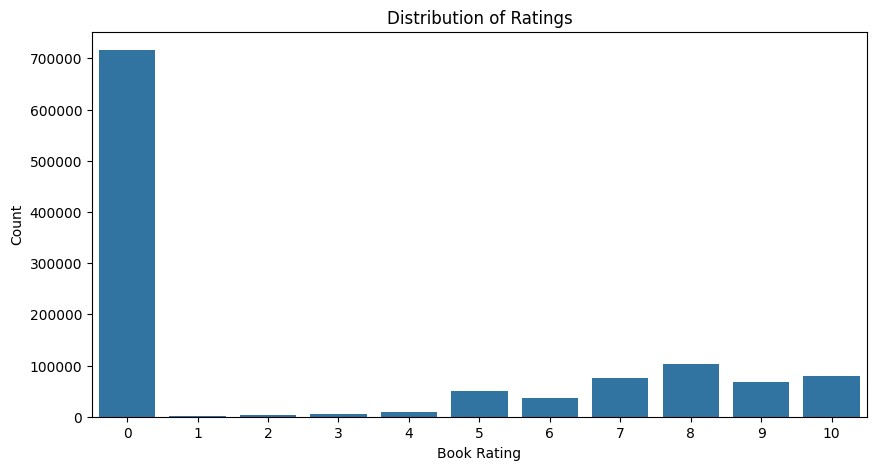

In [35]:
print("Data Types of Ratings Dataset:")
print("\n", df_ratings.dtypes)

print("\nNumber of unique rated books:", df_ratings["ISBN"].nunique())
print("Number of unique rating users:", df_ratings["User-ID"].nunique())
print("\nMissing values in ratings dataset:\n", df_ratings.isnull().sum())

plt.figure(figsize=(10, 5))
sns.countplot(x="Book-Rating", data=df_ratings)
plt.title("Distribution of Ratings")
plt.xlabel("Book Rating")
plt.ylabel("Count")
plt.show()

### Users Dataset
In this section, we explore the users dataset. We check missing values, user information, and the distribution of age.

Data Types of Users Dataset:

 Age        float64
Country     object
dtype: object

Number of unique users: 278858

Missing values in users dataset:
 Age        110762
Country         0
dtype: int64


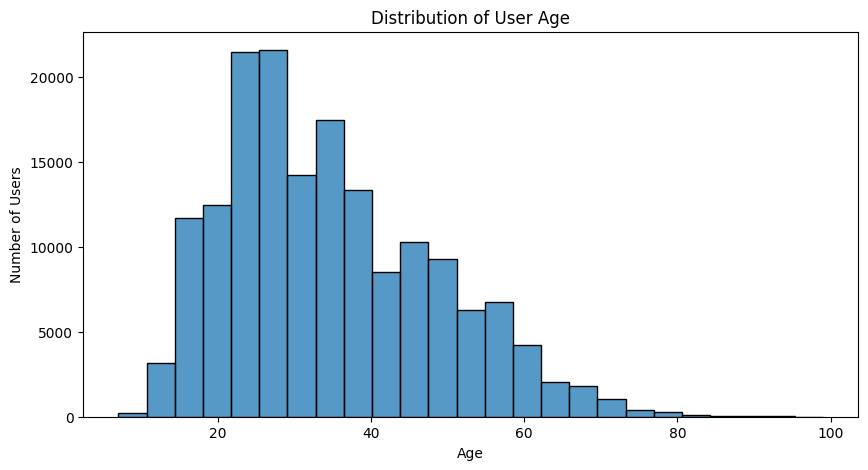

In [50]:
print("Data Types of Users Dataset:")
print("\n", df_users.dtypes)

print("\nNumber of unique users:", df_users.index.nunique())
print("\nMissing values in users dataset:\n", df_users.isnull().sum())

plt.figure(figsize=(10, 5))
sns.histplot(df_users[(df_users["Age"] > 6) & (df_users["Age"] < 100)]["Age"].dropna(), bins=25)
plt.title("Distribution of User Age")
plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.show()

## Advanced Exploratory Data Analysis (EDA)
After exploring the three original datasets separately, this section looks deeper into patterns.

We create derived columns and summary metrics. These help us understand how users interact with books, whether certain groups behave differently, and which variables should or should not be used in the final model.

This part includes derived publication-year features, country-level rating metrics, and age-based statistics.

### Derived Columns
This section of code adds new derived columns to the users dataframe based on the Publishing Year column of the books data. The new columns represent the number of books that a user has read from each decade and the average rating the user has given to books published in that decade.

In [ ]:
df_aux = df_ratings.merge(df_books[['ISBN','Year-Of-Publication']], how = 'left', on = 'ISBN')


df_aux = df_aux[df_aux['Year-Of-Publication'] >= 10]
df_aux['Decade-Of-Publication'] = df_aux['Year-Of-Publication'].apply(lambda row:row // 100* 100)
df_aux = df_aux[['User-ID','Decade-Of-Publication','ISBN']].groupby(['User-ID','Decade-Of-Publication']).count()

df_aux = df_aux.pivot_table(
    index = 'User-ID',
    columns= 'Decade-Of-Publication',
    values = 'ISBN',
    fill_value = 0
).reset_index()

df_aux = df_aux.merge(df_users.reset_index().drop(columns=['Location','Country'], errors='ignore'), on='User-ID')
df_aux.corr(method='pearson').style.background_gradient(cmap='coolwarm')

,User-ID,1300.000000,1800.000000,1900.000000,2000.000000,Age
User-ID,1.000000,0.000222,-0.001531,0.002517,-0.000312,-0.004814
1300.000000,0.000222,1.000000,-0.000022,0.017870,0.021033,-0.003247
1800.000000,-0.001531,-0.000022,1.000000,0.135497,0.053382,0.005912
1900.000000,0.002517,0.017870,0.135497,1.000000,0.672872,0.015324
2000.000000,-0.000312,0.021033,0.053382,0.672872,1.000000,0.013847
Age,-0.004814,-0.003247,0.005912,0.015324,0.013847,1.000000


### Countries Metrics
Below we present basic metrics per country, such as the average scores across countries, and the review frequency (as well as the sample size for each country). 

We remind again that 0-scores represent the purchase of a book and leaving a no score, whereas ratings 1-10 show a customers appreciation of the book.

It is important to notice that all countries are included, disregarding the sample size. This leads to countries inaccurate mean ratings due to limited number of observations within the country. We later investigate countries with bigger sample sizes, so we atempt to extract more informed analytics.

Sample Size graph is splitted into two Reviews Frequency graphs, which are mutually exclusive.

In [ ]:
df_ratings_users = df_ratings.merge(df_users, on = 'User-ID').merge(df_books, on = 'ISBN')

df_no_rating = df_ratings_users[df_ratings_users["Book-Rating"] == 0]
df_rated = df_ratings_users[df_ratings_users["Book-Rating"] > 0]

df_mean_ratings_bycountry = df_rated.groupby('Country')['Book-Rating'].mean().reset_index()
df_samples_sizes_countries = df_ratings_users.groupby('Country')['Book-Rating'].count().reset_index()

df_rating_frequency_leaving_reviews = df_rated.groupby('Country')['Book-Rating'].count().reset_index()
df_rating_frequency_not_leaving_reviews = df_no_rating.groupby('Country')['Book-Rating'].count().reset_index()

fig = px.choropleth(
    df_mean_ratings_bycountry,
    locations='Country',
    locationmode='country names',
    color='Book-Rating',
    title='Average Book Rating per Country',
    hover_data='Book-Rating',
    color_continuous_scale='bluyl'
)
fig.show()

fig = px.choropleth(
    df_samples_sizes_countries,
    locations='Country',
    locationmode='country names',
    color='Book-Rating',
    title='Sample Sizes per Country',
    hover_data='Book-Rating',
    color_continuous_scale='bluyl'
)
fig.show()

fig = px.choropleth(
    df_rating_frequency_leaving_reviews,
    locations='Country',
    locationmode='country names',
    color='Book-Rating',
    title='Reviews Frequency per Country (Leaving Reviews)',
    hover_data='Book-Rating',
    color_continuous_scale='bluyl'
)
fig.show()

fig = px.choropleth(
    df_rating_frequency_not_leaving_reviews,
    locations='Country',
    locationmode='country names',
    color='Book-Rating',
    title='Reviews Frequency per Country (Not Leaving Reviews)',
    hover_data='Book-Rating',
    color_continuous_scale='bluyl'
)
fig.show()

### Metrics for Countries with more than 100 reviews, having left a review

We decided that 100 reviews might be a good starting point, since under Central Limit Theorem, samples with above 30 observations allow the sample mean to be treated as approximately normally distributed, allowing for more reliable estimate of the means.
In the first graph we have the mean book ratings per country, where we can see that the majority falls between 7 and 9, with average mean of all of about 7.6.

In the second graph we have computed the standard deviation of each country's rating, where we see that the average st. dev. across all is about 1.8. Considering this information, we get that for a randomly picked review we can say that the score might be roughly between 6 and 9.5 (mean ± std). As one can imagine, on the scale 1-10, this suggests that happy customers may tend to leave reviews more often in comparison with unhappy ones, making it a reasonable hypothesis for investigating a positive bias.

In [ ]:
df_std_ratings = df_rated.groupby('Country')['Book-Rating'].std().reset_index()

df_ratings_frequency_morethan_100 = df_rating_frequency_leaving_reviews[df_rating_frequency_leaving_reviews['Book-Rating']>=100]['Country']

df_mean_ratings_morethan_100 = df_mean_ratings_bycountry[df_mean_ratings_bycountry['Country'].isin(df_ratings_frequency_morethan_100)]
df_std_ratings_morethan_100 = df_std_ratings[df_std_ratings['Country'].isin(df_ratings_frequency_morethan_100)]

average_mean_countries = df_mean_ratings_morethan_100['Book-Rating'].mean()
average_std_countries = df_std_ratings_morethan_100['Book-Rating'].mean()

print(f"Average Mean across countries, having more than 100 reviews, is {round(average_mean_countries, 2)}, Average Standard Deviation is {round(average_std_countries, 2)}.")

fig = px.choropleth(
    df_mean_ratings_morethan_100,
    locations='Country',
    locationmode='country names',
    color='Book-Rating',
    title='Average Book Rating per Country for Countries with more than 100 reviews',
    hover_data='Book-Rating',
    color_continuous_scale='bluyl'
)
fig.show()

fig = px.choropleth(
    df_std_ratings_morethan_100,
    locations='Country',
    locationmode='country names',
    color='Book-Rating',
    title='Standard Deviation Book Rating per Country for Countries with more than 100 reviews',
    hover_data='Book-Rating',
    color_continuous_scale='bluyl'
)
fig.show()

Average Mean across countries, having more than 100 reviews, is 7.63, Average Standard Deviation is 1.74.


### Age Statistics
Below we have plotted the distribution of all users' ages, and the one of the ages of the users that have left a review for a book. Note that the distribution of the users that have purchased a book and have not left a review is identical as the second graph and therefore we have left it out.

We have also calculated the average review per age category, together with the st. deviation, in hopes to see a distinctive pattern, which does not appear here.

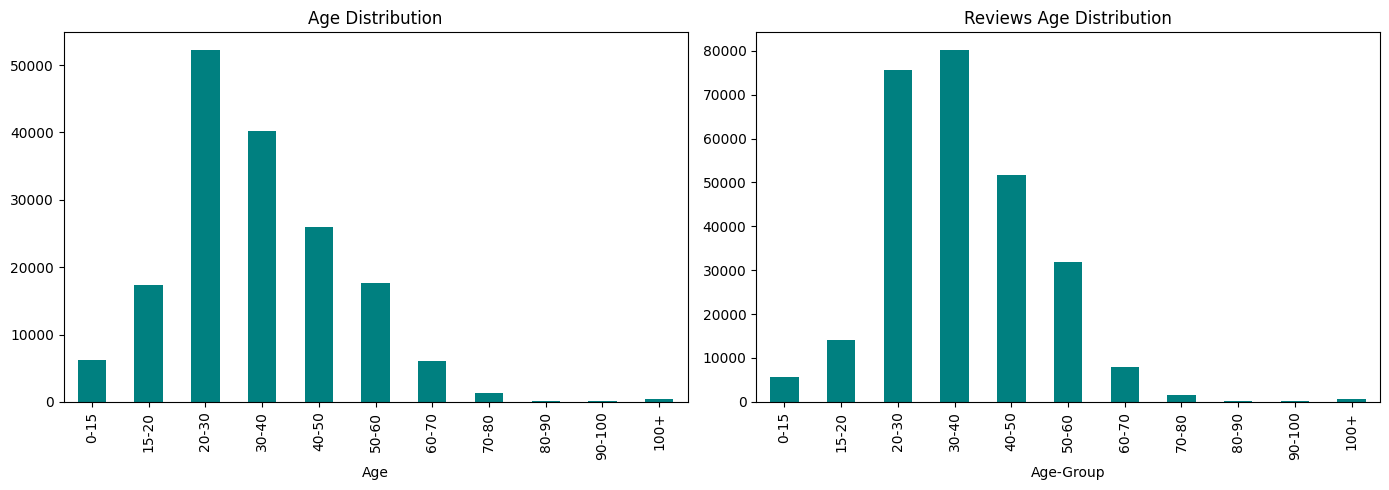

In [ ]:
df_rated["Age-Group"] = pd.cut(df_rated["Age"], bins=[0, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 300], 
                                labels=["0-15", "15-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80", "80-90", "90-100", "100+"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

df_age = pd.cut(df_users["Age"], bins=[0, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 300], 
                                labels=["0-15", "15-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80", "80-90", "90-100", "100+"]).value_counts().sort_index()
age_distr_plot = df_age.plot(kind = 'bar', ax = ax1, title = 'Age Distribution', color = 'teal')

df_rated_age = df_rated["Age-Group"].value_counts().sort_index()
age_distr_plot = df_rated_age.plot(kind = 'bar', ax = ax2, title = 'Reviews Age Distribution', color = 'teal')

plt.tight_layout()
plt.show()

In [ ]:
df_age_mean_rating = df_rated.groupby("Age-Group")["Book-Rating"].agg(["mean", "std"])

df_age_mean_rating

,mean,std
Age-Group,,
0-15,7.787873,1.900589
15-20,7.616413,1.911247
20-30,7.750960,1.824832
30-40,7.637781,1.844476
40-50,7.778311,1.759924
50-60,7.923684,1.713325
60-70,7.811159,1.809949
70-80,7.704331,1.792948
80-90,7.078067,2.146987


## Two Step Book Recommendation Model

This section builds the recommendation part of the project. The goal of this model is to create a smaller and more relevant set of book recommendations before using a predictive model later. The recommender is based on shared reading behaviour: if users connected to my input books also read another book, that book may be a relevant recommendation.

The system uses a two-step idea. First, the co-reader model finds possible recommendations based on user behaviour. Later, the regression/classification model can rerank these recommendations using extra features.

### Data cleaning and Main table creation
In this section, the ratings, users, and books datasets are merged into one main table called `df_main`. This table contains the user-book interactions together with book information such as title, author, year of publication, and publisher. The country and location columns are removed from this model because they are highly unbalanced. Most observations come from the USA. If we used country as a feature, later calculations could become questionable because the model would mostly learn patterns from US users.

The data is restricted to the top 10 publishers. This keeps the model focused on a smaller and cleaner subset of the data. Extra count features are also created:

`book-read-count`: how often a book title appears in the cleaned data.
`author-read-count`: how often books by the same author appear in the cleaned data.

A separate table, `df_book_list`, is created to store one row per ISBN. This table is used later to display book information in the recommendation output.

In [ ]:
#merge all data into one table - df_main
df_main = pd.merge(df_ratings,df_users, how='left', on='User-ID')
df_main = pd.merge(df_main, df_books, how= 'left', on='ISBN')
df_main = df_main.drop(columns=['Location', 'Country'], errors='ignore')
#restricts data only to top publishers
top_publishers = df_main['Publisher'].value_counts().head(10).index.to_list()
df_main = df_main[df_main['Publisher'].isin(top_publishers)]

#creates book-read-count column
read_count = df_main['Book-Title'].value_counts()
read_count.name = 'book-read-count'

#creates author-read-count column
author_counts = df_main['Book-Author'].value_counts()
author_counts.name = 'author-read-count'

#adds author_counts and read_count to df_main
df_main = pd.merge(df_main, author_counts, how='left', on='Book-Author')
df_main = pd.merge(df_main, read_count, how='left', on='Book-Title')

#create df_book_list table for recommendation system
df_book_list = (
    df_main[
        [
            'ISBN',
            'Book-Title',
            'Book-Author',
            'Year-Of-Publication',
            'Publisher',
            'book-read-count',
            'author-read-count'
        ]
    ]
    .drop_duplicates('ISBN')
    .copy()
)

### Book ISBN search based on title for future actions
This section creates a helper function to search books by title. Since the recommendation model uses ISBNs as input, this function helps find the correct ISBN for a book title.

In [ ]:
def search_books_by_title(search_text, n=10):
    """
    Search books by title so you can find the correct ISBN.
    """
    search_text = str(search_text).lower()

    results = df_book_list[
        df_book_list['Book-Title']
        .astype(str)
        .str.lower()
        .str.contains(search_text, na=False)
    ].copy()

    results = results.sort_values(
        by='book-read-count',
        ascending=False
    )

    return results.head(n)

In [ ]:
search_books_by_title("Angels", n=10) 

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,book-read-count,author-read-count
2638,0345348109,The Killer Angels,Michael Shaara,1993.0,Ballantine Books,128,122
7890,034540727X,The Killer Angels,MICHAEL SHAARA,1996.0,Ballantine Books,128,18
193981,0345322282,The Killer Angels,Michael Shaara,1983.0,Ballantine Books,128,122
3450,0446607274,Angels Flight (Detective Harry Bosch Mysteries),Michael Connelly,2000.0,Warner Books,50,492
2900,0446356611,Rage of Angels,Sidney Sheldon,1988.0,Warner Books,42,854
21304,0446341894,Rage of Angels,Sidney Sheldon,1985.0,Warner Books,42,854
3693,0373711646,Those Christmas Angels (Harlequin Superromance...,Debbie Macomber,2003.0,Harlequin,37,244
17,0140062718,The Rebel Angels,Robertson Davies,1983.0,Penguin Books,25,183
3682,0553568736,A Plague of Angels,Sheri S. Tepper,1994.0,Bantam,20,95
9376,0380773775,Angels Among Us,Don Fearheiley,1993.0,Avon,16,21


### Co-reader vote recommender

#### Recommendation model logic

This section contains the main recommendation function, `recommender(seed_isbns, k)`. The function takes a list of input books and recommends other books based on users who are connected to those input books.

The model uses one main logic: find matched users, look at what else they read, and give votes to those other books. The value of k controls how strict the matching rule is.

If k = 0, any interaction with an input book counts as a match. This gives broader recommendations based on general reading behaviour.

If k > 0, a user only counts as matched if they rated an input book at least k. This gives stricter recommendations based on books users actually rated highly.

For each matched user, the model counts how many input books they matched. This count becomes the vote weight. Every other book read by that user receives votes equal to this weight.

For example, suppose the input books are Book A, Book B, and Book C. If User A read all three books, then with k = 0, User A gives 3 votes to every other book they read. If k = 8 and User A only rated Book A above 8, then User A gives only 1 vote. If User B rated Book A and Book B above 8, then User B gives 2 votes to every other book they read.

The recommender returns a ranked list of candidate books. The most important output columns are:

- `coreader_vote_score`: total weighted votes for the candidate book.
- `matched_reader_count`: number of matched users who read the candidate book.
- `global_reader_count`: number of users in the cleaned dataset who interacted with that ISBN.
book information such as title, author, year, and publisher.

In [56]:
def recommender(seed_isbns, k):
    # Clean input ISBNs
    seed_isbns = [str(isbn).strip() for isbn in seed_isbns]
    seed_isbns = list(set(seed_isbns))

    # Read/interacted events from df_main
    read_events = df_main[["User-ID", "ISBN"]].drop_duplicates()

    # Keep only seed books that exist in df_main
    valid_seed_isbns = [
        isbn for isbn in seed_isbns
        if isbn in set(df_main["ISBN"])
    ]

    print("Input seed ISBNs:", seed_isbns)
    print("Valid seed ISBNs:", valid_seed_isbns)

    if len(valid_seed_isbns) == 0:
        raise ValueError("None of the seed ISBNs exist in df_main.")

    seed_ratings = df_main[(df_main["ISBN"].isin(valid_seed_isbns)) & (df_main["Book-Rating"] >= k)].copy()

    if seed_ratings.empty:
        raise ValueError("No users rated the seed books above or equal to k.")

    user_seed_matches = (seed_ratings.groupby("User-ID")["ISBN"].nunique())
    user_seed_matches.name = "liked_seed_count"
    user_seed_matches = user_seed_matches.reset_index()

    score_column = "liked_seed_count"
    final_score_name = "vote_score"
    print("Matched users:", len(user_seed_matches))



    # Get all other books read by matched users
    candidate_reads = pd.merge(read_events, user_seed_matches, how="inner", on="User-ID")

    # Do not recommend the input seed books
    candidate_reads = candidate_reads[~candidate_reads["ISBN"].isin(valid_seed_isbns)].copy()
    if candidate_reads.empty:
        return pd.DataFrame()

    # Score candidate books
    scores = (
        candidate_reads
        .groupby("ISBN")
        .agg(
            vote_score=(score_column, "sum"),
            matched_reader_count=("User-ID", "nunique")
        ).reset_index())
    scores = scores.rename(columns={"vote_score": final_score_name})

    # Global reader count
    global_reader_counts = (read_events.groupby("ISBN")["User-ID"].nunique())

    global_reader_counts.name = "global_reader_count"
    global_reader_counts = global_reader_counts.reset_index()

    scores = pd.merge(scores, global_reader_counts, how="left", on="ISBN")
    scores = scores.sort_values(by=[final_score_name, "matched_reader_count"], ascending=False)

    recommendations = pd.merge(scores, df_book_list, how="left", on="ISBN")

    return recommendations

### Recommender Test
This section tests the recommender with a selected list of seed books. The same input books are tested with different values of k.

This comparison helps show how the threshold k changes the behaviour of the recommender.

In [52]:
seed_isbns = [
    "0451169530",   # The Stand
    "0451157443",   # Carrie
    "0743424425	",  # The Shining
    "0451184963",   # Insomnia
    "0345337662",   # Interview with the Vampire
    "0440295815",   # Hannibal
    "0399506438",   # Lord of the Flies
    "0345348109"    # The Killer Angels

]

In [57]:
recommender(seed_isbns, k=0)

Input seed ISBNs: ['0345337662', '0743424425', '0440295815', '0451157443', '0399506438', '0451184963', '0345348109', '0451169530']
Valid seed ISBNs: ['0345337662', '0743424425', '0440295815', '0451157443', '0399506438', '0451184963', '0345348109', '0451169530']
Matched users: 443


,ISBN,vote_score,matched_reader_count,global_reader_count,Book-Title,Book-Author,Year-Of-Publication,Publisher,book-read-count,author-read-count
0,0345313860,65,55,143,"The Vampire Lestat (Vampire Chronicles, Book II)",ANNE RICE,1986.0,Ballantine Books,301,656
1,034538475X,53,44,90,The Tale of the Body Thief (Vampire Chronicles...,Anne Rice,1993.0,Ballantine Books,193,2219
2,0345351525,48,44,100,The Queen of the Damned (Vampire Chronicles (P...,Anne Rice,1993.0,Ballantine Books,273,2219
3,0451167317,34,24,68,The Dark Half,Stephen King,1994.0,Signet Book,153,5667
4,0451172817,33,24,70,Needful Things,Stephen King,2004.0,Signet Book,159,5667
...,...,...,...,...,...,...,...,...,...,...
4591,1572972009,1,1,1,The Empty Throne (Xena: Warrior Princess (Berk...,Ru Emerson,1996.0,Berkley Publishing Group,5,14
4592,1572972327,1,1,3,The Thief of Hermes: A Novel (Xena - Warrior P...,Ru Emerson,1997.0,Berkley Publishing Group,4,14
4593,1572972432,1,1,1,Warriors of Virtue: The Novel,Robert Tine,1997.0,Berkley Publishing Group,3,34
4594,2266023039,1,1,10,La Nuit des temps,RenÃ?Â© Barjavel,1988.0,Pocket,24,41


In [54]:
recommender(seed_isbns,k=8)

Input seed ISBNs: ['0345337662', '0743424425', '0440295815', '0451157443', '0399506438', '0451184963', '0345348109', '0451169530']
Valid seed ISBNs: ['0345337662', '0743424425', '0440295815', '0451157443', '0399506438', '0451184963', '0345348109', '0451169530']
Matched users: 298


,ISBN,liked_seed_vote_score,matched_reader_count,global_reader_count,Book-Title,Book-Author,Year-Of-Publication,Publisher,book-read-count,author-read-count
0,0345313860,46,44,143,"The Vampire Lestat (Vampire Chronicles, Book II)",ANNE RICE,1986.0,Ballantine Books,301,656
1,0345351525,38,36,100,The Queen of the Damned (Vampire Chronicles (P...,Anne Rice,1993.0,Ballantine Books,273,2219
2,034538475X,35,33,90,The Tale of the Body Thief (Vampire Chronicles...,Anne Rice,1993.0,Ballantine Books,193,2219
3,0451176464,23,18,68,Gerald's Game,Stephen King,2001.0,Signet Book,138,5667
4,0451167317,22,17,68,The Dark Half,Stephen King,1994.0,Signet Book,153,5667
...,...,...,...,...,...,...,...,...,...,...
3803,2266067249,1,1,3,L'Homme qui murmurait Ã?Â l'oreille des chevaux,Nicholas Evans,1997.0,Pocket,6,9
3804,2266082272,1,1,1,Les vendanges tardives,FranÃ?Â§oise Dorin,1999.0,Pocket,2,3
3805,2266102931,1,1,1,Fritna,GisÃ?Â¨le Halimi,2001.0,Pocket,1,1
3806,2266104535,1,1,19,Et Si C'Etait Vrai / If This Were Only True,Marc Levy,2001.0,Pocket,38,92


### Extra Data cleaning for Regression

In [55]:
#creates book-rate-count column
df_main = df_main[df_main['Book-Rating'] != 0]
rate_count = df_main['Book-Title'].value_counts()
rate_count.name = 'book-rate-count'

#adds rate_count to df_main
df_main = pd.merge(df_main, rate_count, how= 'left', on='Book-Title')

median_age = df_main['Age'].median()
df_main['Age'] = df_main['Age'].fillna(median_age)
K = 8
df_main['rating-over-k'] = df_main['Book-Rating'].apply(lambda row: 1 if row >= K else 0)

display(df_main)

NUM_COLS = [
    'book-rate-count',
    'book-read-count',
    'author-read-count',
    'Year-Of-Publication',
    'Age',
]
CAT_COLS = [
    'Publisher',
]
TARGET = [
    'rating-over-k'
]

,User-ID,ISBN,Book-Rating,Age,Book-Title,Book-Author,Year-Of-Publication,Publisher,author-read-count,book-read-count,book-rate-count_x,rating-over-k,book-rate-count_y
0,276747,0671537458,9,25.0,Waiting to Exhale,Terry McMillan,1995.0,Pocket,419,88,17,1,17
1,276755,0451166892,5,32.0,The Pillars of the Earth,Ken Follett,1996.0,Signet Book,821,228,87,0,87
2,276762,0380711524,5,25.0,See Jane Run,Joy Fielding,1992.0,Avon,182,46,16,0,16
3,276772,0553572369,7,35.0,Pay Dirt (Mrs. Murphy Mysteries (Paperback)),RITA MAE BROWN,1996.0,Bantam,383,26,8,0,8
4,276788,0345443683,8,35.0,"Blackwood Farm (Rice, Anne, Vampire Chronicles.)",ANNE RICE,2003.0,Ballantine Books,656,49,20,1,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80769,276688,0553575090,7,35.0,Deception on His Mind,ELIZABETH GEORGE,1998.0,Bantam,279,89,25,0,25
80770,276688,0553575104,6,35.0,In Pursuit of the Proper Sinner,Elizabeth George,2000.0,Bantam Books,512,79,20,0,20
80771,276688,0671015591,2,35.0,Tiger's Palette (Caroline Canfield Mysteries),Jacqueline Fiedler,1998.0,Pocket,5,3,2,0,2
80772,276688,0671563149,6,35.0,MUDDY WATER (Peter Bartholomew Mysteries),Sally Gunning,1997.0,Pocket,30,3,1,0,1
